The aim of this notebook is to show how a model trained with snntorch can be tested with asynctorch.

In [1]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF
import tonic
import tonic.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Load data

In [55]:
timestep_size = 20000
transform = tonic.transforms.Compose([
    #transforms.Denoise(filter_time=10000),
    transforms.Downsample(spatial_factor=0.25),
    transforms.ToFrame(sensor_size=(32, 32, 2), time_window=timestep_size)
])
train_dataset = tonic.datasets.DVSGesture(save_to="./data", transform=transform, train=True)
collate_fn = tonic.collation.PadTensors(batch_first=False)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

In [66]:
class SNNTorchCNN(nn.Module):
    def __init__(self, beta=0.7, threshold=0.3):
        super(SNNTorchCNN, self).__init__()
        spike_grad = surrogate.fast_sigmoid()
        self.conv1 = nn.Conv2d(2, 12, 5, bias=False)
        self.pool1 = nn.AvgPool2d(2)
        self.lif1 = snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad)
        self.conv2 = nn.Conv2d(12, 32, 5, bias=False)
        self.pool2 = nn.AvgPool2d(2)
        self.lif2 = snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(800, 11, bias=False)
        self.lif3 = snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad)
        self.reset_state()

    def forward(self, x):
        spk_count = 0
        x = self.conv1(x)
        x = self.pool1(x)
        x, self.mem1 = self.lif1(x, self.mem1)
        spk_count += x.sum().item()
        x = self.conv2(x)
        x = self.pool2(x)
        x, self.mem2 = self.lif2(x, self.mem2)
        spk_count += x.sum().item()
        x = self.flatten(x)
        x = self.fc1(x)
        x, self.mem3 = self.lif3(x, self.mem3)
        spk_count += x.sum().item()
        return x, spk_count

    def reset_state(self):
        self.mem1 = self.lif1.init_leaky()
        self.mem2 = self.lif2.init_leaky()
        self.mem3 = self.lif3.init_leaky()

    def compute_n_neurons(self, input_shape, device):
        x = torch.zeros((1, *input_shape), device=device)
        self.reset_state()
        x = self(x)
        n_neurons = self.mem1.shape.numel() + self.mem2.shape.numel() + self.mem3.shape.numel()
        self.reset_state()
        return n_neurons

snntorch_model = SNNTorchCNN().to(device)
n_epochs = 10
optimizer = torch.optim.Adam(snntorch_model.parameters(), lr=1e-3)
print(f"Number of parameters: {sum(p.numel() for p in snntorch_model.parameters())}")
print(f"Number of neurons: {snntorch_model.compute_n_neurons((2, 32, 32), device)}")
loss_fn = SF.ce_rate_loss()
accuracy_function = SF.accuracy_rate

losses = []
accuracies = []
for epoch in range(n_epochs):
    batch_iter = iter(train_dataloader)
    for data, targets in tqdm(batch_iter):
        data = data.to(device)
        targets = targets.to(device)
        snntorch_model.reset_state()

        # Forward pass
        ys = []
        spk_count_total = 0
        for t in range(data.shape[0]):
            ts_data = data[t]
            spk_out, spk_count = snntorch_model(ts_data)
            spk_count_total += spk_count
            ys.append(spk_out) 
        #print(f"Average spiking rate: {spk_count_total / data.shape[0]}")
        y = torch.stack(ys)
        loss = loss_fn(y, targets)
        losses.append(loss.item())
        accuracy = accuracy_function(y, targets)
        accuracies.append(accuracy)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Number of parameters: 19000
Number of neurons: 3163


100%|██████████| 17/17 [01:40<00:00,  5.90s/it]


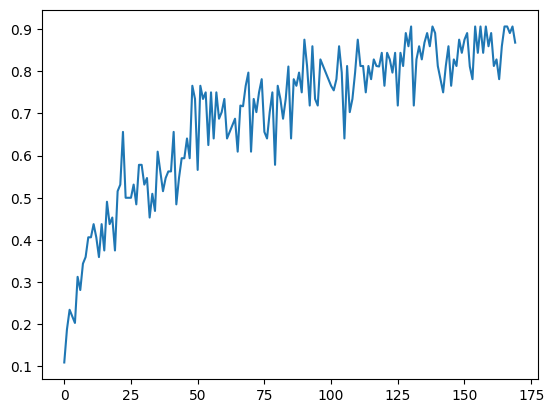

In [67]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(accuracies)